In [2]:

# --- Import libraries ---
import json                        # to read JSON files
import pandas as pd                # to work with tables (DataFrames)
import numpy as np                 # for numbers and random seed
import matplotlib.pyplot as plt    # for plots
import seaborn as sns              # for nicer plots
from wordcloud import WordCloud

In [3]:
plt.rcParams['figure.figsize'] = (12, 5)   # default size for all plots
sns.set_style('whitegrid')                  # clean white background for plots
# --- Configuration variables ---
DATASET_PATH = "data/arxiv-metadata-oai-snapshot.json"  # path to the data file
SAMPLE_SIZE  = 5000    # how many papers we want to load (not the full dataset)
RANDOM_SEED  = 42      # for reproducibility (same results every run)
np.random.seed(RANDOM_SEED)   # fix the random seed

print(f"Dataset : {DATASET_PATH}")
print(f"Sample  : {SAMPLE_SIZE} papers")
print(f"Seed    : {RANDOM_SEED}")

Dataset : data/arxiv-metadata-oai-snapshot.json
Sample  : 5000 papers
Seed    : 42


In [6]:
rows = []   # empty list, we will fill it with one dict per paper

with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):

        # Stop when we reach our limit
        if i >= SAMPLE_SIZE:
            break

        # Parse each line as JSON (each line = one paper)
        try:
            p = json.loads(line)

            # Extract only the fields we need
            rows.append({
                'id'         : p.get('id', ''),
                'title'      : p.get('title', '').replace('\n', ' ').strip(),
                'abstract'   : p.get('abstract', '').replace('\n', ' ').strip(),
                'authors'    : p.get('authors', ''),
                'submitter'  : p.get('submitter', ''),
                'categories' : p.get('categories', ''),
                'journal_ref': p.get('journal-ref', '') or '',
                'doi'        : p.get('doi', '') or '',
                'comments'   : p.get('comments', '') or '',
                'report_no'  : p.get('report-no', '') or '',
                'license'    : p.get('license', '') or '',
                'date'       : p.get('update_date', ''),
            })

        except:
            # Skip any line that can't be parsed
            continue

# Convert our list of dicts into a DataFrame (a table)
df = pd.DataFrame(rows)

df.shape # (rows, columns)
df.columns
df.head(5)

,id,title,abstract,authors,submitter,categories,journal_ref,doi,comments,report_no,license,date
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturbati...,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Pavel Nadolsky,hep-ph,"Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,"37 pages, 15 figures; published version",ANL-HEP-PR-07-12,,2008-11-26
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",Ileana Streinu and Louis Theran,Louis Theran,math.CO cs.CG,,,To appear in Graphs and Combinatorics,,http://arxiv.org/licenses/nonexclusive-distrib...,2008-12-13
2,0704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is describe...,Hongjun Pan,Hongjun Pan,physics.gen-ph,,,"23 pages, 3 figures",,,2008-01-13
3,0704.0004,A determinant of Stirling cycle numbers counts...,We show that a determinant of Stirling cycle n...,David Callan,David Callan,math.CO,,,11 pages,,,2007-05-23
4,0704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,In this paper we show how to compute the $\Lam...,Wael Abu-Shammala and Alberto Torchinsky,Alberto Torchinsky,math.CA math.FA,"Illinois J. Math. 52 (2008) no.2, 681-689",,,,,2013-10-15


In [7]:
print(f"Total papers  : {len(df)}")
print(f"Total columns : {df.shape[1]}")

# Missing values = empty cells in our table
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Data types = what kind of data is in each column
print(f"\nData types per column:")
print(df.dtypes)

Total papers  : 5000
Total columns : 12

Missing values per column:
id             0
title          0
abstract       0
authors        0
submitter      0
categories     0
journal_ref    0
doi            0
comments       0
report_no      0
license        0
date           0
dtype: int64

Data types per column:
id             object
title          object
abstract       object
authors        object
submitter      object
categories     object
journal_ref    object
doi            object
comments       object
report_no      object
license        object
date           object
dtype: object


In [8]:
# --- Step 1 : Extract main category ---
# lambda = a small anonymous function applied to each row
df['main_category'] = df['categories'].apply(
    lambda x: x.split()[0].split('.')[0] if x else 'unknown'
    # x.split()[0]        → take first word  ("cs.LG" → "cs.LG")
    # .split('.')[0]      → take part before dot ("cs.LG" → "cs")
    # if x else 'unknown' → handle empty strings
)

# --- Step 2 : Count how many papers per category ---
cat_counts = df['main_category'].value_counts()  # sorted by frequency

print(f"Unique main categories : {df['main_category'].nunique()}")
print(f"\nTop 10 categories :")
print(cat_counts.head(10))

Unique main categories : 18

Top 10 categories :
main_category
math        999
astro-ph    972
cond-mat    898
physics     345
hep-ph      326
hep-th      305
quant-ph    257
cs          250
gr-qc       166
math-ph     101
Name: count, dtype: int64


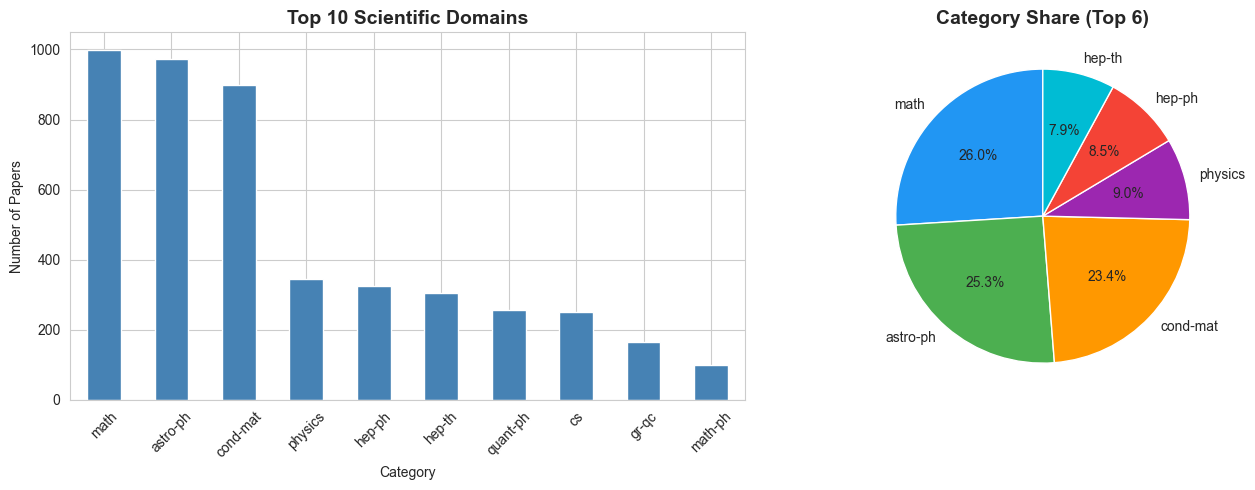

In [9]:
# --- Step 3 : Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots(1, 2) = 1 row, 2 columns of plots → side by side

# Left plot : Bar chart (top 10)
cat_counts.head(10).plot(
    kind='bar',
    ax=axes[0],           # put it on the LEFT axis
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Top 10 Scientific Domains', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)   # rotate labels so they don't overlap

# Right plot : Pie chart (top 6 only, pie gets messy with too many slices)
cat_counts.head(6).plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',    # show percentage on each slice
    colors=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4'],
    startangle=90         # start from top
)
axes[1].set_title('Category Share (Top 6)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')    # hide the ugly default ylabel

plt.tight_layout()        # auto-adjust spacing between subplots
plt.show()


Average words per abstract : 122.1
Min words                  : 2
Max words                  : 318
Average chars per abstract : 802.5


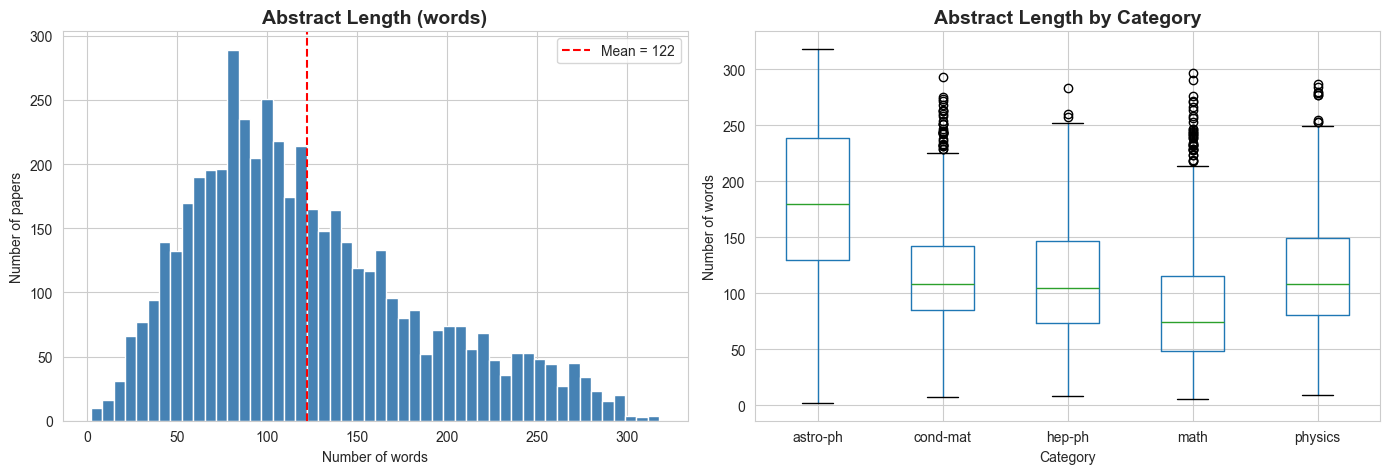

In [10]:
# BLOCK 6 : Abstract Length Analysis
# ============================================================
# Goal : How long are the abstracts? Do categories differ?

# --- Step 1 : Count words and characters ---
df['nb_words'] = df['abstract'].apply(lambda x: len(x.split()))
# x.split() splits the text by spaces → gives a list of words
# len(...)  counts how many words

df['nb_chars'] = df['abstract'].apply(lambda x: len(x))
# len(x) on a string = number of characters

print(f"Average words per abstract : {df['nb_words'].mean():.1f}")
print(f"Min words                  : {df['nb_words'].min()}")
print(f"Max words                  : {df['nb_words'].max()}")
print(f"Average chars per abstract : {df['nb_chars'].mean():.1f}")

# --- Step 2 : Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left : Histogram — how many papers have X words?
axes[0].hist(df['nb_words'], bins=50, color='steelblue', edgecolor='white')
# bins=50 → divide the range into 50 buckets

axes[0].axvline(
    df['nb_words'].mean(),      # draw a vertical line at the mean
    color='red',
    linestyle='--',
    label=f"Mean = {df['nb_words'].mean():.0f}"
)
axes[0].set_title('Abstract Length (words)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Number of papers')
axes[0].legend()

# Right : Boxplot — compare length across top 5 categories
top5_cats = df['main_category'].value_counts().head(5).index
df_top5   = df[df['main_category'].isin(top5_cats)]
# .isin() keeps only rows where main_category is in our top5 list

df_top5.boxplot(column='nb_words', by='main_category', ax=axes[1])
# boxplot shows: median, quartiles, and outliers per group
axes[1].set_title('Abstract Length by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of words')
plt.suptitle('')   # remove the automatic pandas title above the plot

plt.tight_layout()
plt.show()


In [11]:
from wordcloud import WordCloud
from collections import Counter
import re

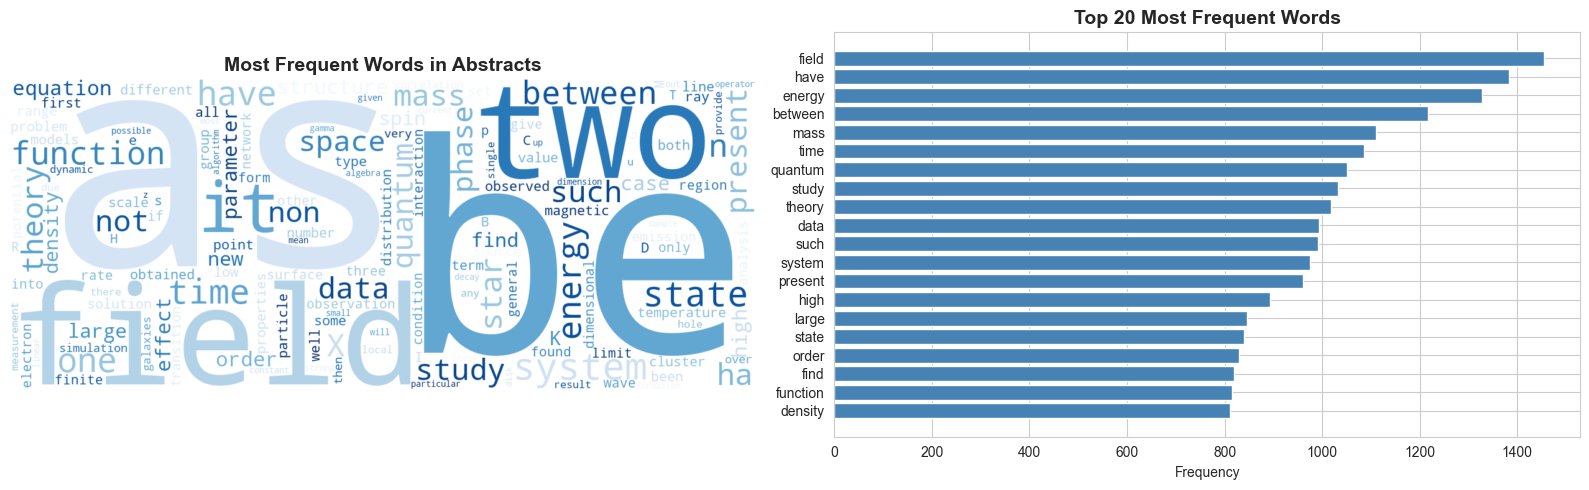

In [12]:
# --- Step 1 : Combine all abstracts into one big text ---
all_text = ' '.join(df['abstract'].tolist())
# tolist() → converts the column to a Python list
# ' '.join(...) → joins all texts with a space between them

# --- Step 2 : Define stopwords (common words we want to ignore) ---
custom_stopwords = {
    'the','a','an','and','or','but','in','on','at','to',
    'for','of','with','by','from','is','are','was','were',
    'this','that','these','those','we','our','their','its',
    'also','however','thus','hence','while','since','using',
    'used','use','show','shown','shows','based','paper',
    'propose','proposed','method','approach','model','results',
    'can','may','which','where','when','how','than','more'
}

# --- Step 3 : Generate the word cloud ---
wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    max_words=150,            # show at most 150 words
    stopwords=custom_stopwords,
    colormap='Blues',         # color theme
    collocations=False        # don't pair words together
).generate(all_text)

# --- Step 4 : Count top 20 words manually for bar chart ---
words = re.findall(r'\b[a-z]{4,}\b', all_text.lower())
# re.findall = find all matches of a pattern
# r'\b[a-z]{4,}\b' = words with at least 4 letters (no short words like "the")

words     = [w for w in words if w not in custom_stopwords]
top_words = Counter(words).most_common(20)
# Counter counts occurrences, .most_common(20) returns the top 20

words_list  = [w[0] for w in top_words]   # just the word
counts_list = [w[1] for w in top_words]   # just the count

# --- Step 5 : Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc, interpolation='bilinear')   # display the word cloud image
axes[0].axis('off')                            # hide axes (no x/y ticks needed)
axes[0].set_title('Most Frequent Words in Abstracts', fontsize=14, fontweight='bold')

axes[1].barh(words_list[::-1], counts_list[::-1], color='steelblue')
# [::-1] reverses the list so the most frequent word is at the TOP
axes[1].set_title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

Year range             : 2007 → 2025
Papers with valid date : 5000


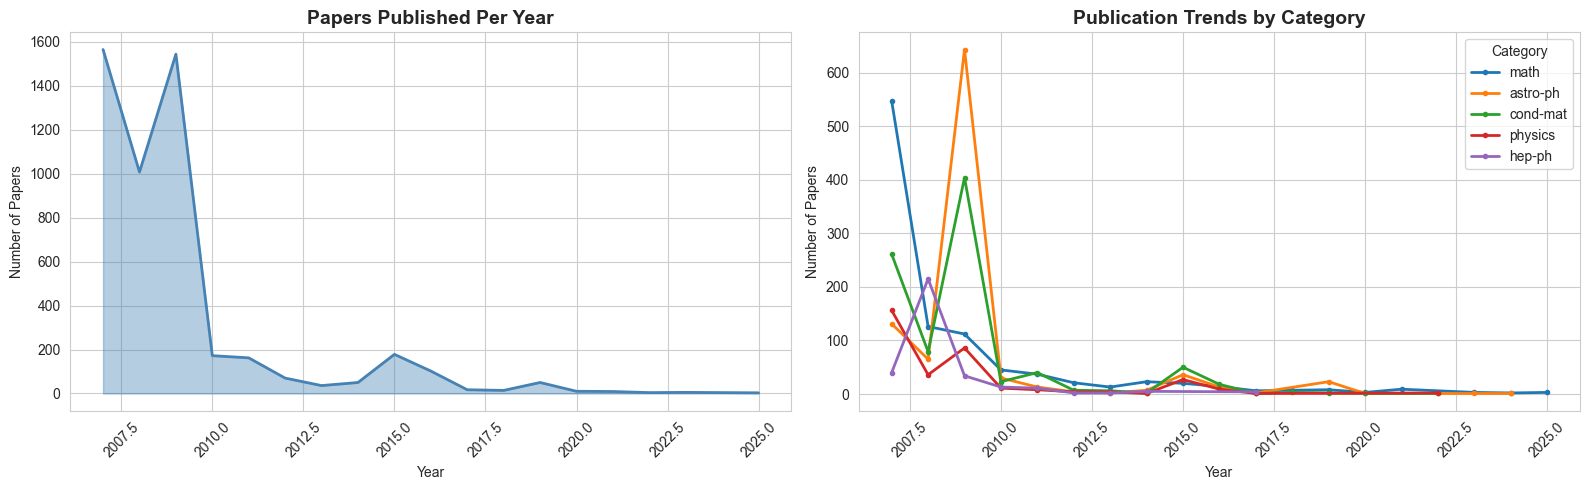

In [13]:
# Goal : How many papers were published each year?

# --- Step 1 : Extract year from the date column ---
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
# pd.to_datetime() converts a string like "2021-03-15" to a real date
# errors='coerce' → if the date is invalid, put NaT (Not a Time) instead of crashing
# .dt.year → extract just the year number

# --- Step 2 : Remove invalid years ---
df_valid = df[df['year'].between(1990, 2025)]
print(f"Year range             : {df_valid['year'].min()} → {df_valid['year'].max()}")
print(f"Papers with valid date : {len(df_valid)}")

# --- Step 3 : Count papers per year ---
papers_per_year = df_valid['year'].value_counts().sort_index()
# .sort_index() → sort by year (not by count)

# --- Step 4 : Filter top 5 categories for the second plot ---
top5_cats = df['main_category'].value_counts().head(5).index
df_top5   = df_valid[df_valid['main_category'].isin(top5_cats)]

# --- Step 5 : Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left : Area + line chart for total papers per year
axes[0].fill_between(papers_per_year.index, papers_per_year.values,
                     alpha=0.4, color='steelblue')  # shaded area
axes[0].plot(papers_per_year.index, papers_per_year.values,
             color='steelblue', linewidth=2)         # line on top
axes[0].set_title('Papers Published Per Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)

# Right : One line per category
for cat in top5_cats:
    cat_data = df_top5[df_top5['main_category'] == cat]
    yearly   = cat_data['year'].value_counts().sort_index()
    axes[1].plot(yearly.index, yearly.values,
                 marker='o', markersize=3, linewidth=2, label=cat)

axes[1].set_title('Publication Trends by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Papers')
axes[1].legend(title='Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Numerical features created:
  - nb_words         : word count of abstract
  - nb_chars         : character count of abstract
  - nb_authors       : number of authors
  - has_journal      : has journal reference (0/1)
  - has_doi          : has DOI (0/1)
  - has_comments     : has comments (0/1)
  - abstract_density : words/chars ratio
  - year             : publication year


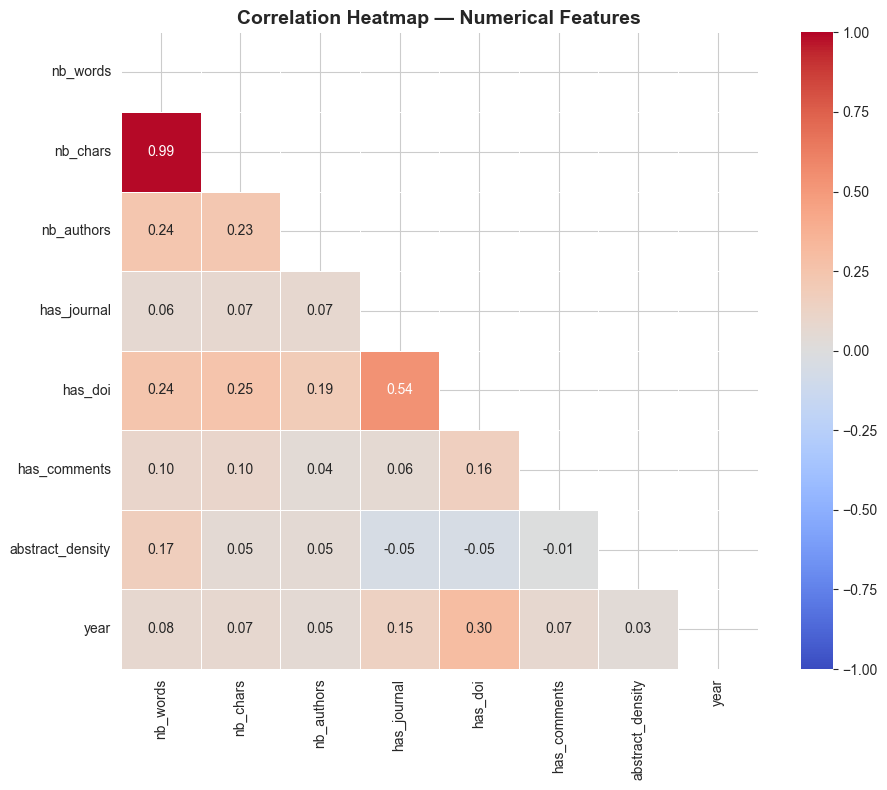

Plot saved → reports/correlation_heatmap.png


In [14]:
# Goal : Do some features tend to go together? (e.g. more authors = more words?)

# --- Step 1 : Create numeric features ---
df['nb_authors'] = df['authors'].apply(lambda x: len(x.split(',')) if x else 0)
# Count commas in the authors string → approximate number of authors

df['has_journal']  = (df['journal_ref'] != '').astype(int)
df['has_doi']      = (df['doi'] != '').astype(int)
df['has_comments'] = (df['comments'] != '').astype(int)
# (column != '').astype(int) → True/False converted to 1/0

df['abstract_density'] = df['nb_words'] / df['nb_chars'].replace(0, 1)
# ratio words/chars = average word length (lower = longer words)
# .replace(0, 1) avoids dividing by zero

print("Numerical features created:")
print("  - nb_words         : word count of abstract")
print("  - nb_chars         : character count of abstract")
print("  - nb_authors       : number of authors")
print("  - has_journal      : has journal reference (0/1)")
print("  - has_doi          : has DOI (0/1)")
print("  - has_comments     : has comments (0/1)")
print("  - abstract_density : words/chars ratio")
print("  - year             : publication year")

# --- Step 2 : Compute correlation matrix ---
num_cols = ['nb_words','nb_chars','nb_authors',
            'has_journal','has_doi','has_comments',
            'abstract_density','year']

corr_matrix = df[num_cols].corr()
# .corr() computes Pearson correlation between all pairs of columns
# Values range from -1 (opposite) to +1 (same direction), 0 = no link

# --- Step 3 : Plot heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))

# mask = hide the upper triangle (it's a mirror of the lower triangle)
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,      # show the numbers inside each cell
    fmt='.2f',       # format: 2 decimal places
    cmap='coolwarm', # red = positive, blue = negative
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/correlation_heatmap.png")
